In [54]:
# Import required libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Pharma_Industry.csv")

# Display first five rows
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


#Basic Information of the Dataset

The following functions provide important information about the dataset:
- Shape of the dataset
- Column names
- Data types
- Missing values
- Statistical summary

In [55]:
# Shape of dataset
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset: (500, 6)

Columns:
Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB

Missing Values:
Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (B

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


#Feature Distribution Analysis

Feature distribution helps us understand how the values are spread across each numerical feature.

We use:
- Histogram to observe frequency distribution.
- Box Plot to detect outliers.


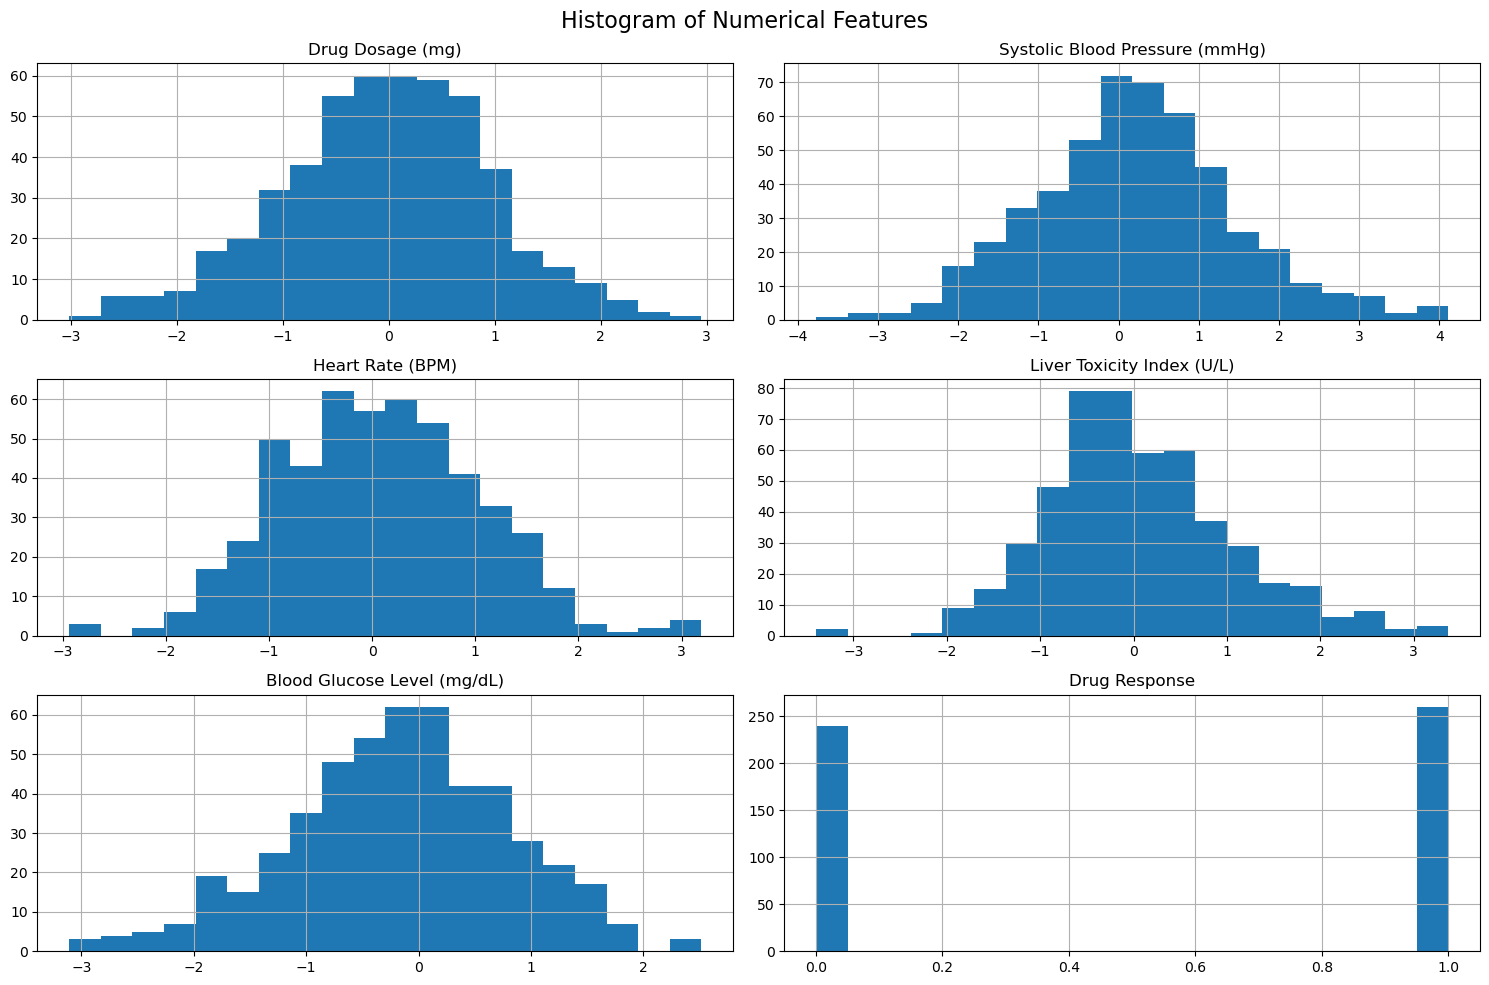

In [56]:
import matplotlib.pyplot as plt

# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Histograms
df[numeric_columns].hist(figsize=(15,10), bins=20)

plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

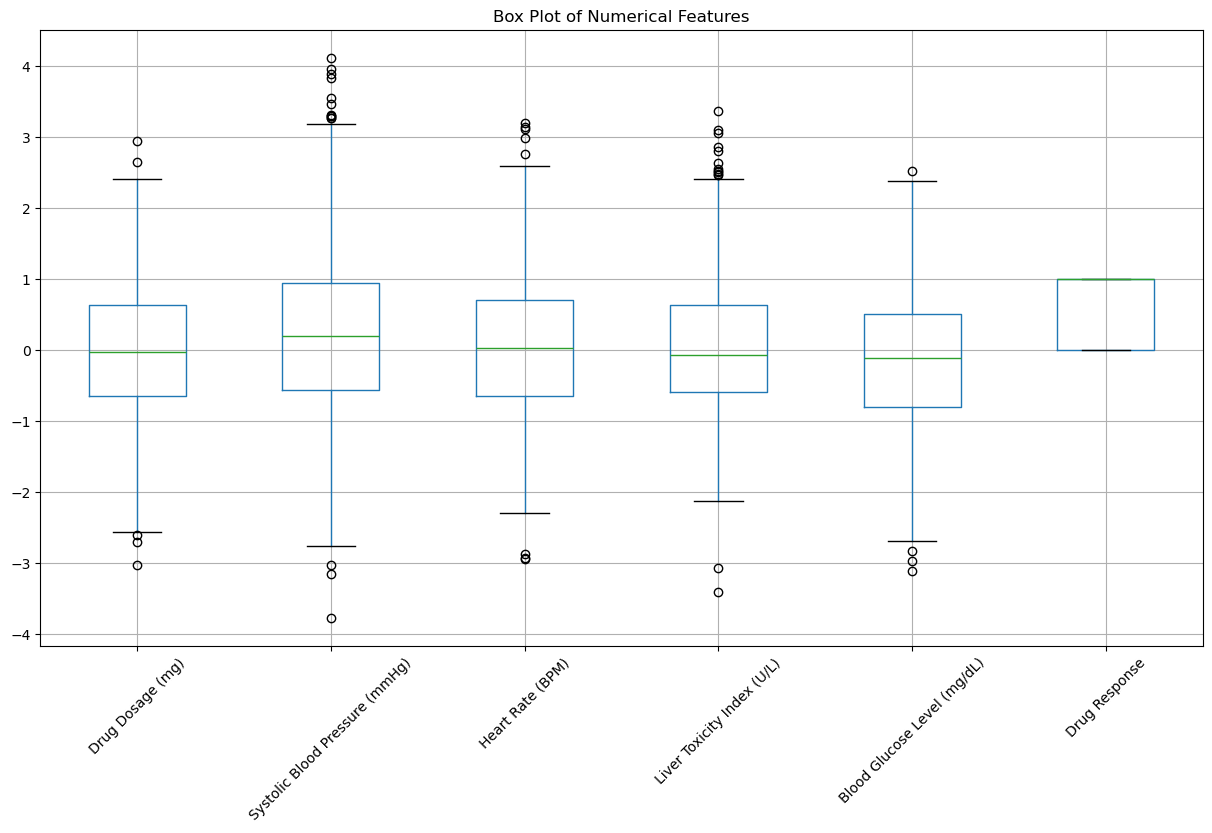

In [57]:
# Box Plots

plt.figure(figsize=(15,8))

df[numeric_columns].boxplot(rot=45)

plt.title("Box Plot of Numerical Features")
plt.show()

In [58]:
# Remove Outliers using IQR Method

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]



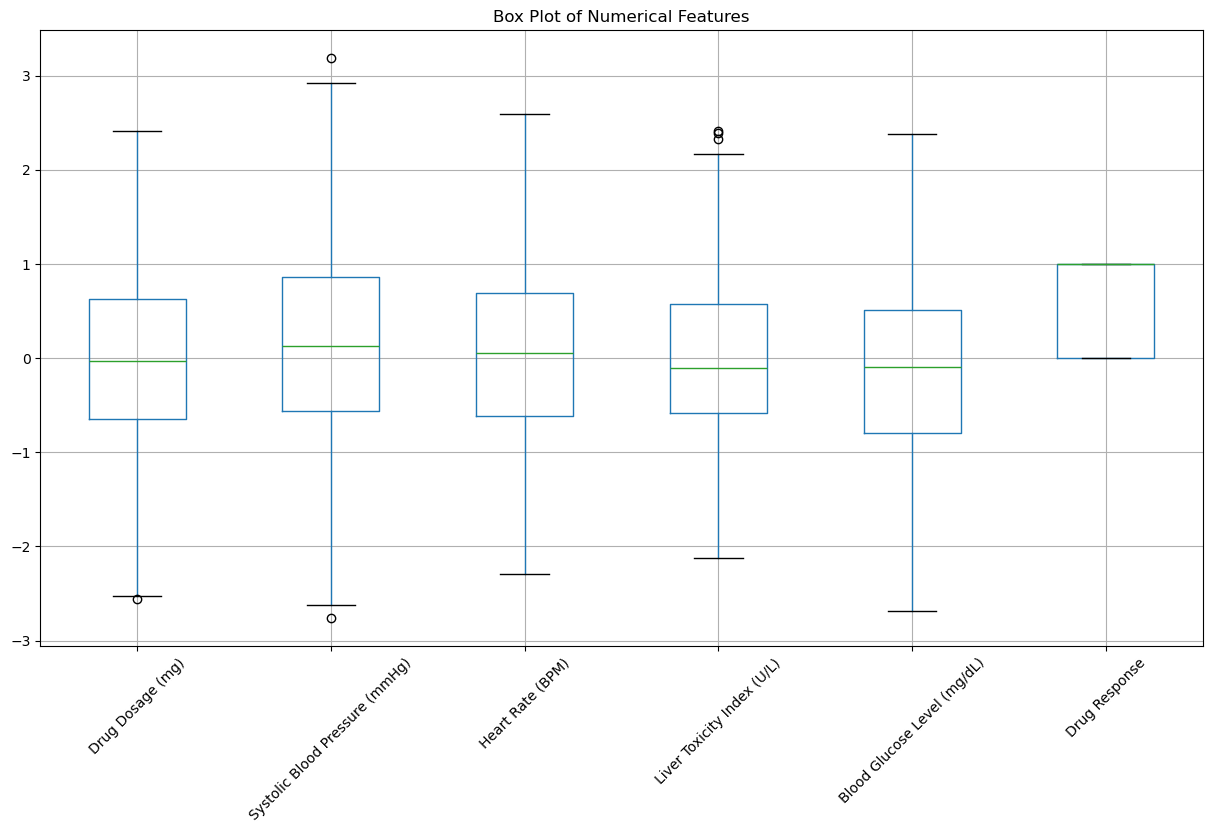

In [59]:
# Box Plots

plt.figure(figsize=(15,8))

df[numeric_columns].boxplot(rot=45)

plt.title("Box Plot of Numerical Features")
plt.show()

#Correlation Analysis

Correlation measures the relationship between numerical variables.

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate little or no relationship.

A heatmap is used to visualize these correlations.

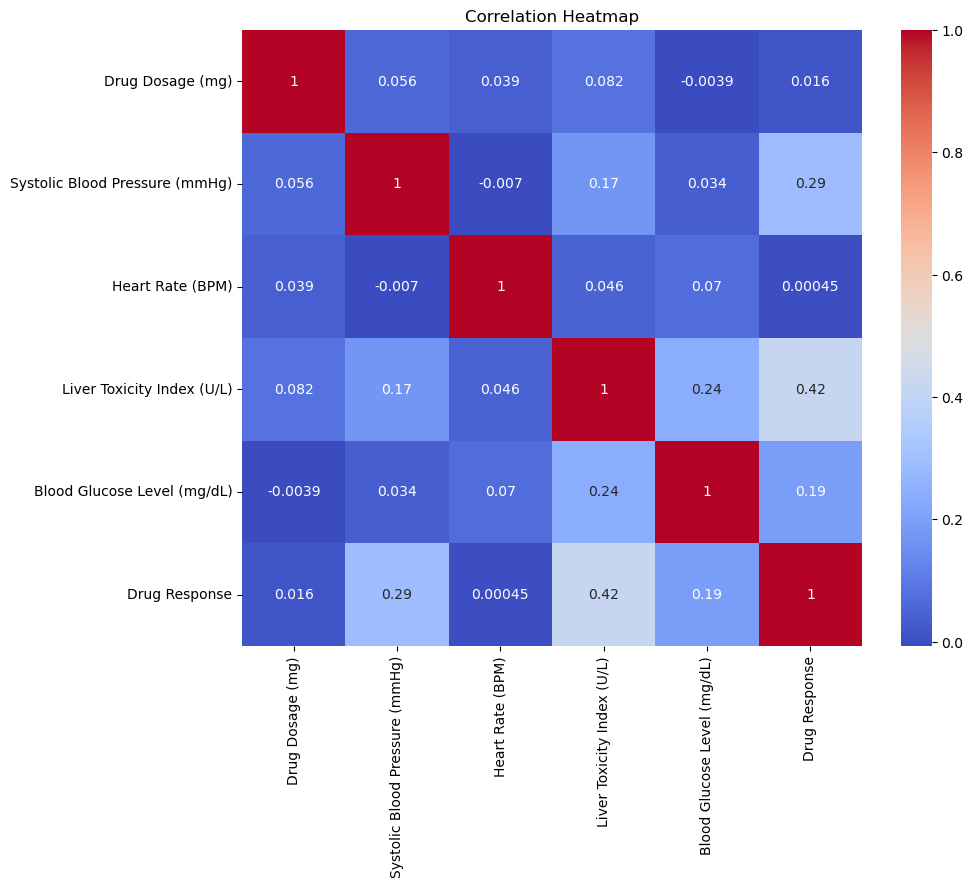

In [60]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Conclusion

From the Exploratory Data Analysis (EDA), the dataset was successfully loaded and examined for its structure, data types, missing values, and statistical summary. Histograms, box plots, and density plots provided insights into the distribution of numerical features and helped identify potential outliers. Finally, the correlation heatmap illustrated the relationships among the numerical variables, which is useful for understanding feature dependencies before applying machine learning algorithms.

Task 2: Data Preprocessing

1.Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical variables must be converted into numerical values using encoding techniques such as Label Encoding or One-Hot Encoding.

In this dataset, all input features are numerical. The target variable (`Drug Response`) is checked to determine whether encoding is required.

In [61]:
print(df.dtypes)

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Drug Response'] = le.fit_transform(df['Drug Response'])

df.head()
print("No categorical variables found. Encoding is not required.")

No categorical variables found. Encoding is not required.


#Train-Test Split

The dataset is divided into two parts:

- Training Set (80%): Used to train the machine learning model.
- Testing Set (20%): Used to evaluate the model's performance on unseen data.

The target variable is **Drug Response**, while the remaining columns are used as input features.

In [63]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop("Drug Response", axis=1)

# Target
y = df["Drug Response"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (370, 5)
X_test Shape  : (93, 5)
y_train Shape : (370,)
y_test Shape  : (93,)


#Conclusion

During preprocessing, the dataset was checked for categorical variables. Since the input features are numerical, no feature encoding was required. If the target variable contained categorical labels, Label Encoding was applied. Finally, the dataset was divided into training (80%) and testing (20%) sets using `train_test_split()` to prepare the data for machine learning model development.

Task 3: Data Visualization

Scatter Plots and Pair Plots

Data visualization helps us understand the relationships between variables and identify patterns, trends, clusters, and potential outliers.

In this task:
- Scatter plots are used to visualize relationships between two numerical variables.
- Pair plots provide a comprehensive view of relationships among all numerical features and their distributions.

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

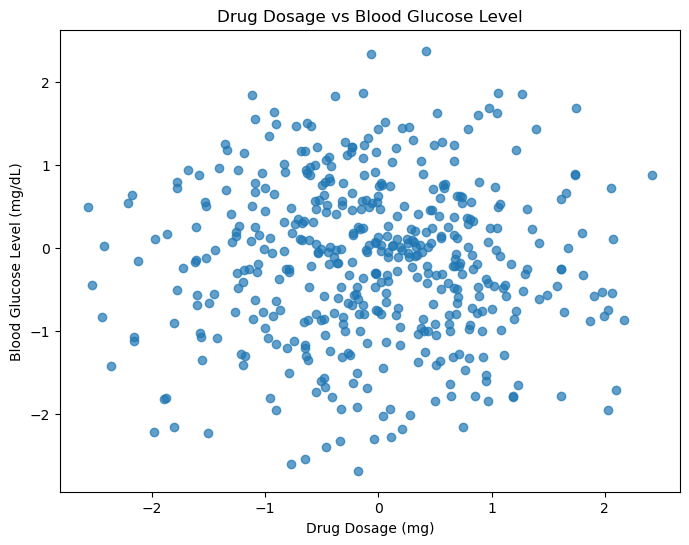

In [65]:
# Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df["Drug Dosage (mg)"],
    df["Blood Glucose Level (mg/dL)"],
    alpha=0.7
)

plt.title("Drug Dosage vs Blood Glucose Level")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")

plt.show()

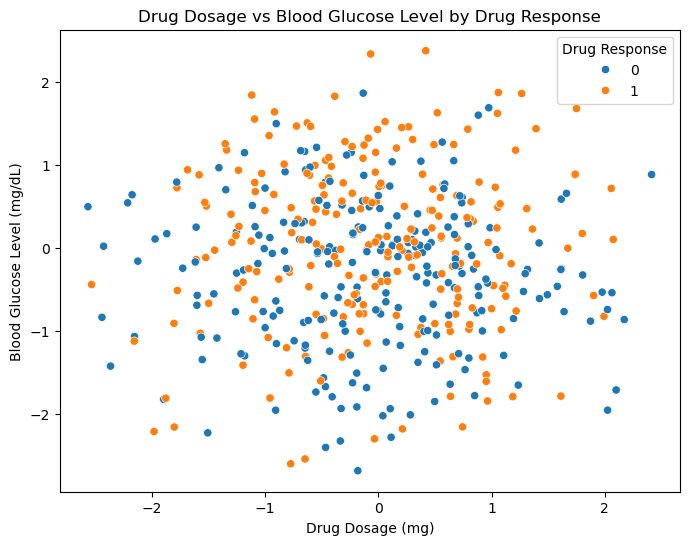

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Drug Dosage (mg)",
    y="Blood Glucose Level (mg/dL)",
    hue="Drug Response"
)

plt.title("Drug Dosage vs Blood Glucose Level by Drug Response")

plt.show()

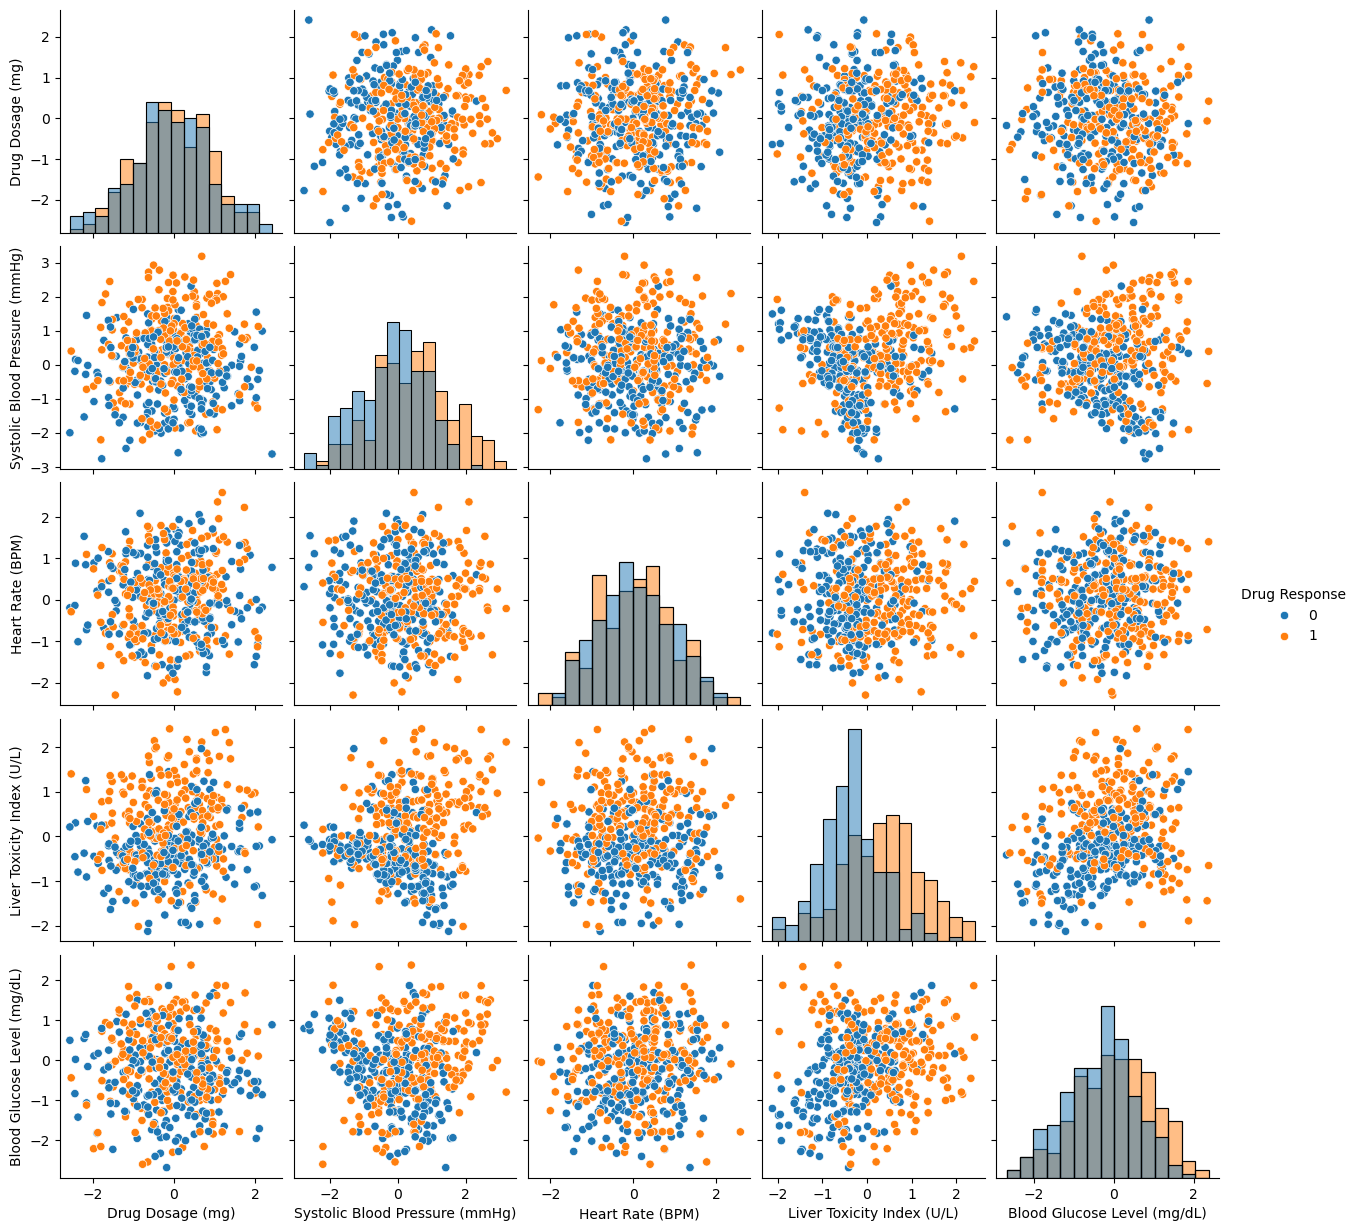

In [67]:
# Pair Plot

sns.pairplot(
    df,
    hue="Drug Response",
    diag_kind="hist"
)

plt.show()

#Class Distribution

Visualizing the target variable helps determine whether the dataset is balanced or imbalanced.

- Balanced Dataset: Classes contain nearly equal numbers of samples.
- Imbalanced Dataset: One class contains significantly more samples than the other, which may affect model performance.

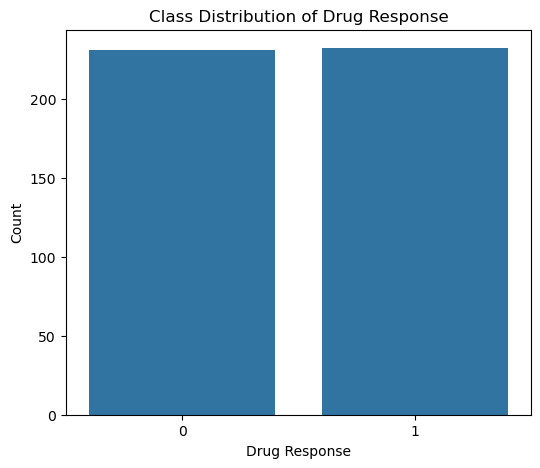

In [68]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Drug Response"
)

plt.title("Class Distribution of Drug Response")
plt.xlabel("Drug Response")
plt.ylabel("Count")

plt.show()

In [69]:
# Percentage distribution

class_distribution = df["Drug Response"].value_counts(normalize=True) * 100

print("Class Distribution (%)")
print(class_distribution)

Class Distribution (%)
Drug Response
1    50.107991
0    49.892009
Name: proportion, dtype: float64


#Task 4:Support Vector Machine (SVM) Implementation

#Implementing the SVM Classifier

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It works by finding the optimal hyperplane that best separates different classes in the dataset.

In this task, an SVM classifier is implemented using the scikit-learn library.

In [70]:
# Import SVM classifier
from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC(kernel='rbf', random_state=42)

In [71]:
# Train the model
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


#Model Evaluation

After training, the model is tested using the testing dataset. The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

These metrics help assess the classification performance of the SVM model.

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict on test data
y_pred = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Print Metrics
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.6881720430107527
Precision: 0.7021276595744681
Recall   : 0.6875
F1-Score : 0.6947368421052632


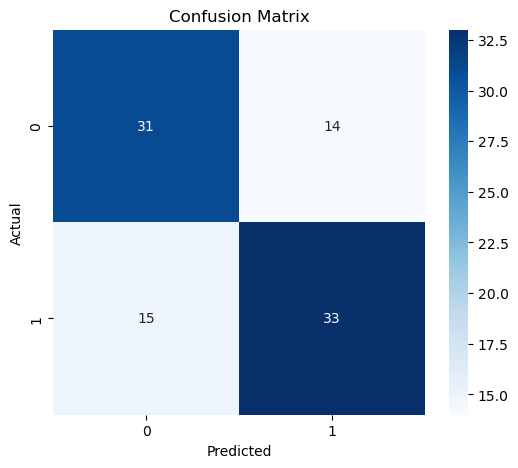

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [74]:
print("Classification Report\n")

print(classification_report(y_test, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.67      0.69      0.68        45
           1       0.70      0.69      0.69        48

    accuracy                           0.69        93
   macro avg       0.69      0.69      0.69        93
weighted avg       0.69      0.69      0.69        93



#Conclusion

A Support Vector Machine (SVM) classifier was successfully implemented using the scikit-learn library. The model was trained on the training dataset and evaluated using the testing dataset.

Performance was assessed using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report. These evaluation metrics provide a comprehensive understanding of the model's classification performance and its ability to correctly predict drug response.

#Task 5:Visualization of SVM Results

#Visualization of Classification Results

After training the Support Vector Machine (SVM) model, it is important to visualize its prediction performance on the testing dataset.

The following visualizations are used:

- Actual vs Predicted Class Distribution
- Confusion Matrix

These plots help evaluate how well the SVM classifier predicts the drug response.

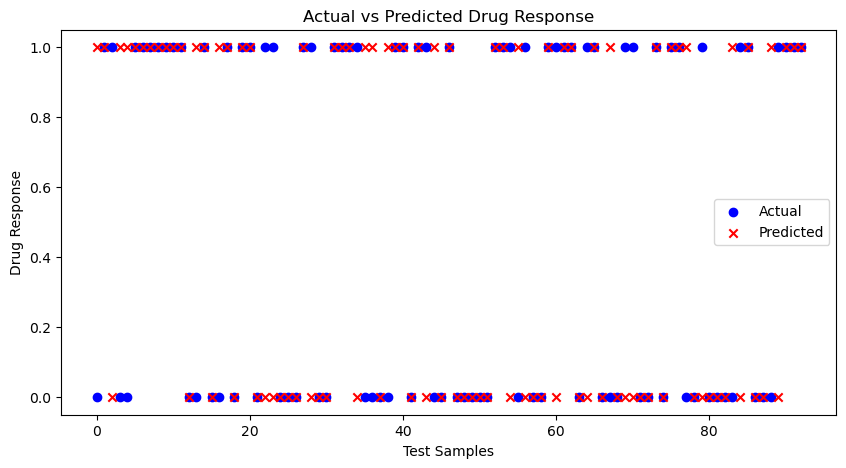

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(range(len(y_test)), y_test, label="Actual", color="blue")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", color="red", marker="x")

plt.title("Actual vs Predicted Drug Response")
plt.xlabel("Test Samples")
plt.ylabel("Drug Response")
plt.legend()

plt.show()

In [76]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,0,1
1,1,1
2,1,0
3,0,1
4,0,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


#Task 6: Parameter Tuning and Optimization

#Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning is the process of selecting the best parameters for a machine learning model to improve its performance.

For the SVM classifier, the following hyperparameters are tuned:

- Kernel: linear, rbf, poly
- C (Regularization Parameter): 0.1, 1, 10, 100
- Gamma: scale, auto

GridSearchCV performs cross-validation to evaluate all possible parameter combinations and selects the best-performing model.

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Parameter Grid
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Grid Search
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Train
grid.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [78]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [79]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

In [80]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred_best)

print("Optimized Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_best))

Optimized Accuracy: 0.6881720430107527

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.69      0.68        45
           1       0.70      0.69      0.69        48

    accuracy                           0.69        93
   macro avg       0.69      0.69      0.69        93
weighted avg       0.69      0.69      0.69        93



#Conclusion

GridSearchCV was used to optimize the hyperparameters of the Support Vector Machine classifier. Different combinations of kernel type, regularization parameter (C), and gamma were evaluated using 5-fold cross-validation. The best parameter combination was selected automatically based on accuracy, resulting in an optimized SVM model with improved classification performance.

#Task 7: Comparison and Analysis

#Comparison of Different SVM Kernels

Support Vector Machine (SVM) supports multiple kernel functions. Each kernel maps the input data into a different feature space, which can affect classification performance.

The kernels compared are:
- Linear Kernel
- Polynomial Kernel
- Radial Basis Function (RBF) Kernel

The accuracy of each kernel is evaluated on

In [81]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# Linear Kernel
linear_model = SVC(kernel='linear', random_state=42)
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_acc = accuracy_score(y_test, linear_pred)

# Polynomial Kernel
poly_model = SVC(kernel='poly', random_state=42)
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)
poly_acc = accuracy_score(y_test, poly_pred)

# RBF Kernel
rbf_model = SVC(kernel='rbf', random_state=42)
rbf_model.fit(X_train, y_train)
rbf_pred = rbf_model.predict(X_test)
rbf_acc = accuracy_score(y_test, rbf_pred)

# Comparison Table
comparison = pd.DataFrame({
    'Kernel':['Linear','Polynomial','RBF'],
    'Accuracy':[linear_acc, poly_acc, rbf_acc]
})

comparison

,Kernel,Accuracy
0,Linear,0.709677
1,Polynomial,0.677419
2,RBF,0.688172


#Strengths of SVM

- SVM performed well on the pharmaceutical dataset due to the numerical nature of the features.
- It effectively classified the drug response using multiple medical measurements.
- The model can handle high-dimensional data efficiently.
- Hyperparameter tuning further improved the classification performance.

#Weaknesses of SVM

- SVM training becomes slower for very large datasets.
- Choosing the appropriate kernel and hyperparameters requires experimentation.
- The model is less interpretable compared to algorithms such as Decision Trees.
- Performance may decrease if the dataset contains significant noise or overlapping classes.

#Analysis Based on EDA

- Histograms and density plots showed the distribution of numerical features.
- Box plots helped identify potential outliers.
- Scatter plots indicated relationships among features.
- Correlation analysis showed how strongly variables were related.
- The class distribution plot indicated whether the dataset was balanced or imbalanced, which directly affects classification performance.

#Practical Applications of SVM

Support Vector Machine is widely used in many real-world classification problems.

Examples include:

- Medical diagnosis (Disease Prediction)
- Drug response prediction
- Cancer detection
- Face recognition
- Handwritten digit recognition
- Spam email detection
- Credit card fraud detection
- Customer churn prediction
- Text and sentiment classification

For pharmaceutical datasets, SVM helps predict whether a patient is likely to respond positively or negatively to a drug based on medical measurements. This enables healthcare professionals to make better treatment decisions and supports personalized medicine.